In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
dataDirList = ['archive/GarbageClassification']
# dataDirList = ['/content/drive/MyDrive/archive/Garbage classification/Garbage classification']

selectedClasses = ['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']

In [5]:
df = pd.read_csv("Original.csv")

In [6]:
imgPaths = []
labels = []
for dataDir in dataDirList:
    for className in os.listdir(dataDir):
        if className in selectedClasses :
            classPath = os.path.join(dataDir,className)
            for img in os.listdir(classPath):
                imgPath = os.path.join(classPath,img)
                imgPaths.append(imgPath)
                labels.append(className)

# Convert the 2 lists to dataframe to easy use
df = pd.DataFrame({
    'imgPath':imgPaths,
    'label':labels
})

df = df.sample(frac=1).reset_index(drop=True)            # Shuffle

df

,imgPath,label
0,archive/GarbageClassification\paper\paper211.jpg,paper
1,archive/GarbageClassification\metal\metal106.jpg,metal
2,archive/GarbageClassification\cardboard\cardbo...,cardboard
3,archive/GarbageClassification\cardboard\cardbo...,cardboard
4,archive/GarbageClassification\cardboard\cardbo...,cardboard
...,...,...
2522,archive/GarbageClassification\paper\paper583.jpg,paper
2523,archive/GarbageClassification\plastic\plastic3...,plastic
2524,archive/GarbageClassification\paper\paper420.jpg,paper
2525,archive/GarbageClassification\paper\paper351.jpg,paper


In [7]:
df['label'].value_counts()

label
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64

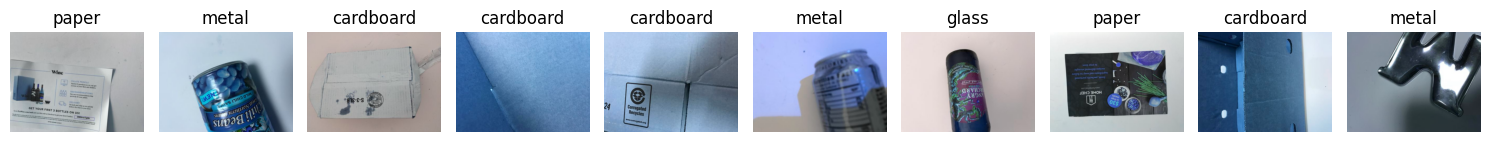

In [8]:
def plot_images_from_df(df, num_images=3):
    # Set up the matplotlib figure and axes
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    # Loop through the number of images you want to display
    for i in range(num_images):
        # Read the image from the path
        image_path = df.iloc[i]['imgPath']
        label = df.iloc[i]['label']

        # Load image using OpenCV and convert from BGR to RGB for matplotlib
        image = cv2.imread(image_path)
        # image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Plot the image on the corresponding subplot
        axes[i].imshow(image)
        axes[i].set_title(label)  # Set the title as the label
        axes[i].axis('off')       # Hide axis for a cleaner look

    plt.tight_layout()
    plt.show()

# Call the function to plot images
plot_images_from_df(df, num_images=10)  # Specify the number of images to plot

In [9]:
df_gaussian_blur = df.copy()

In [10]:
# Function to apply Gaussian blur and update DataFrame with new image paths
def apply_gaussian_blur_to_paths(df, save_path):
    for idx, row in df.iterrows():
        # Read the original image
        image_path = row['imgPath']
        # image = cv2.imread(image_path)

        # Apply Gaussian Blur
        # blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

        # Save the blurred image to a new file
        filename = os.path.basename(image_path)
        blurred_image_path = os.path.join(save_path, f"blurred_{filename}")
        # cv2.imwrite(blurred_image_path, blurred_image)

        # Update the DataFrame with the new image path
        df.at[idx, 'imgPath'] = blurred_image_path
        
# Example: Update DataFrame with blurred images saved to a new folder
apply_gaussian_blur_to_paths(df_gaussian_blur, save_path='Gaussian_Blured')  # Replace with your save path
# apply_gaussian_blur_to_paths(df_gaussian_blur, save_path='/content/drive/MyDrive/Gaussian_Blured')  # Replace with your save path

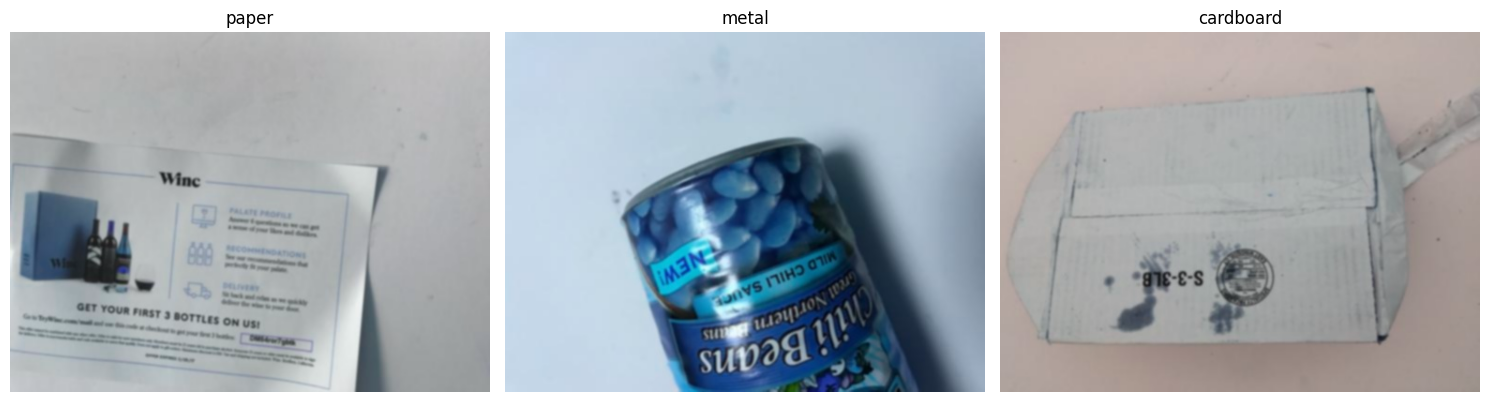

In [11]:
plot_images_from_df(df_gaussian_blur,3)

In [12]:
df_edges = df.copy()

In [13]:
# Function to apply Edge Detection and update DataFrame with new image paths
def apply_edge_detection_to_paths(df, save_path):
    for idx, row in df.iterrows():
        # Read the original image
        image_path = row['imgPath']
        # image = cv2.imread(image_path)

        # Apply Gaussian Blur
        # edges = cv2.Canny(image, 100, 200)

        # Save the blurred image to a new file
        filename = os.path.basename(image_path)
        edges_image_path = os.path.join(save_path, f"edges_{filename}")
        print(edges_image_path)
        # cv2.imwrite(edges_image_path, edges)

        # Update the DataFrame with the new image path
        df.at[idx, 'imgPath'] = edges_image_path

# Example: Update DataFrame with blurred images saved to a new folder
apply_edge_detection_to_paths(df_edges, save_path='edges')  # Replace with your save path
# apply_edge_detection_to_paths(df_edges, save_path='/content/drive/MyDrive/edges')  # Replace with your save path

edges\edges_paper211.jpg
edges\edges_metal106.jpg
edges\edges_cardboard185.jpg
edges\edges_cardboard5.jpg
edges\edges_cardboard157.jpg
edges\edges_metal355.jpg
edges\edges_glass96.jpg
edges\edges_paper176.jpg
edges\edges_cardboard94.jpg
edges\edges_metal363.jpg
edges\edges_paper507.jpg
edges\edges_paper562.jpg
edges\edges_cardboard120.jpg
edges\edges_metal167.jpg
edges\edges_paper259.jpg
edges\edges_glass298.jpg
edges\edges_metal197.jpg
edges\edges_paper482.jpg
edges\edges_plastic294.jpg
edges\edges_paper254.jpg
edges\edges_metal177.jpg
edges\edges_paper433.jpg
edges\edges_metal187.jpg
edges\edges_paper270.jpg
edges\edges_paper319.jpg
edges\edges_plastic18.jpg
edges\edges_metal297.jpg
edges\edges_plastic256.jpg
edges\edges_paper214.jpg
edges\edges_paper417.jpg
edges\edges_glass316.jpg
edges\edges_plastic117.jpg
edges\edges_trash96.jpg
edges\edges_glass255.jpg
edges\edges_plastic162.jpg
edges\edges_metal364.jpg
edges\edges_paper592.jpg
edges\edges_paper193.jpg
edges\edges_plastic229.jpg

In [14]:
df_gaussian_blur

,imgPath,label
0,Gaussian_Blured\blurred_paper211.jpg,paper
1,Gaussian_Blured\blurred_metal106.jpg,metal
2,Gaussian_Blured\blurred_cardboard185.jpg,cardboard
3,Gaussian_Blured\blurred_cardboard5.jpg,cardboard
4,Gaussian_Blured\blurred_cardboard157.jpg,cardboard
...,...,...
2522,Gaussian_Blured\blurred_paper583.jpg,paper
2523,Gaussian_Blured\blurred_plastic364.jpg,plastic
2524,Gaussian_Blured\blurred_paper420.jpg,paper
2525,Gaussian_Blured\blurred_paper351.jpg,paper


In [15]:
df_edges

,imgPath,label
0,edges\edges_paper211.jpg,paper
1,edges\edges_metal106.jpg,metal
2,edges\edges_cardboard185.jpg,cardboard
3,edges\edges_cardboard5.jpg,cardboard
4,edges\edges_cardboard157.jpg,cardboard
...,...,...
2522,edges\edges_paper583.jpg,paper
2523,edges\edges_plastic364.jpg,plastic
2524,edges\edges_paper420.jpg,paper
2525,edges\edges_paper351.jpg,paper


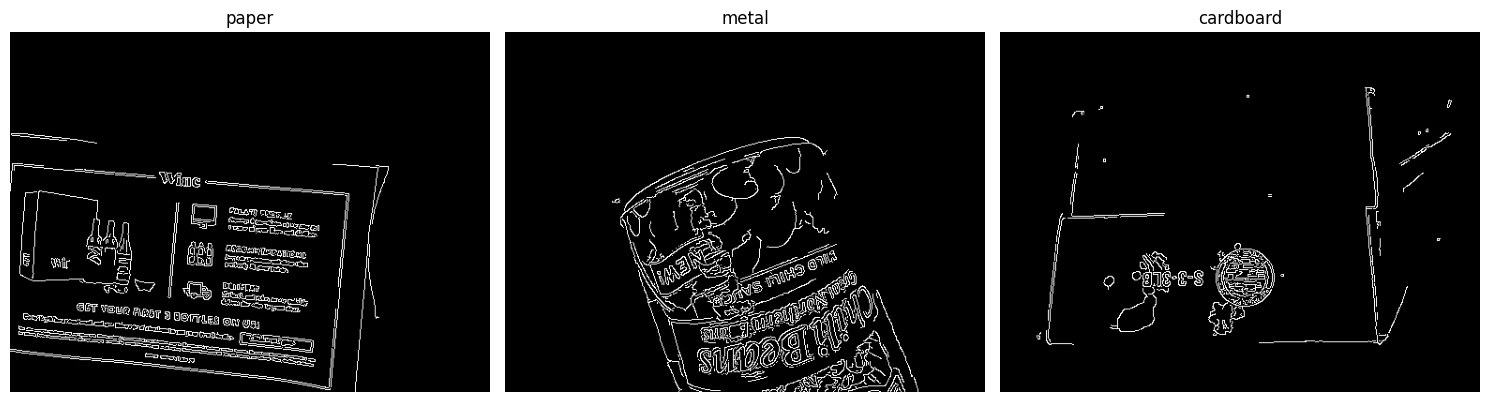

In [16]:
plot_images_from_df(df_edges,3)

In [17]:
df.to_csv("Original.csv")
df_gaussian_blur.to_csv("Gaussian.csv")
df_edges.to_csv("Edges.csv")

In [18]:
def preprocess_images_and_labels(df, target_size=(224, 224), classes=None):
    # If no classes list is provided, extract unique labels from the DataFrame
    if classes is None:
        classes = df['label'].unique().tolist()

    preprocessed_images = []
    preprocessed_labels = []

    for _, row in df.iterrows():
        img_path = row['imgPath']
        label = row['label']

        # Step 1: Load the image using OpenCV
        img = cv2.imread(img_path)

        # Step 2: Resize the image to the target size
        img_resized = cv2.resize(img, target_size)

        # Step 3: Normalize the image pixel values to [0, 1]
        img_normalized = img_resized / 255.0

        # Append the preprocessed image to the list
        preprocessed_images.append(img_normalized)

        # Step 4: One-hot encode the label
        label_one_hot = np.zeros(len(classes))
        label_one_hot[classes.index(label)] = 1

        # Append the one-hot encoded label to the list
        preprocessed_labels.append(label_one_hot)

    # Convert lists to NumPy arrays
    preprocessed_images = np.array(preprocessed_images)
    preprocessed_labels = np.array(preprocessed_labels)

    return preprocessed_images, preprocessed_labels

# Example usage with your DataFrame (df containing imgPath and label columns):
target_size = (224, 224)
classes = df['label'].unique().tolist()  # Get unique classes from the 'label' column

# Preprocess images and labels
preprocessed_images, preprocessed_labels = preprocess_images_and_labels(df_edges, target_size=target_size, classes=classes)

# Check the results
print(preprocessed_images.shape)
print(preprocessed_labels.shape)

(2527, 224, 224, 3)
(2527, 6)


In [19]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(preprocessed_images, preprocessed_labels, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}, Validation data shape: {X_val.shape}")

Training data shape: (2021, 224, 224, 3), Validation data shape: (506, 224, 224, 3)


In [21]:
import cv2
import pandas as pd

# Initialize the feature detector
sift = cv2.SIFT_create()
akaze = cv2.AKAZE_create()

# Define a function to apply on each image path
def compute_features_sift(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        keypoints, descriptors = sift.detectAndCompute(image, None)
        descriptors = np.float32(descriptors)
        return keypoints, descriptors
    else:
        return None, None

# Apply the function to each image path in df_edges and store the result in two separate columns
df_edges["sift_keypoint"], df_edges["sift_descriptor"] = zip(*df_edges["imgPath"].apply(compute_features_sift))
df_gaussian_blur["sift_keypoint"], df_gaussian_blur["sift_descriptor"] = zip(*df_gaussian_blur["imgPath"].apply(compute_features_sift))

def compute_features_akaze(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        keypoints, descriptors = akaze.detectAndCompute(image, None)
        descriptors = np.float32(descriptors)
        return keypoints, descriptors
    else:
        return None, None

df_edges["akaze_keypoint"], df_edges["akaze_descriptor"] = zip(*df_edges["imgPath"].apply(compute_features_akaze))
df_gaussian_blur["akaze_keypoint"], df_gaussian_blur["akaze_descriptor"] = zip(*df_gaussian_blur["imgPath"].apply(compute_features_akaze))



In [33]:
len(df_edges["sift_keypoint"][1])

560

In [25]:
df_gaussian_blur.to_csv("Gaussian.csv")
df_edges.to_csv("Edges.csv")

In [ ]:
# #create a system to find correspondences between several images( using keypoints matching) and apply it in recognition
# #use sift and akaze to find keypoints and descriptors
# #use flann to match the descriptors
# #use homography to find the transformation matrix
# #use warp perspective to apply the transformation matrix to the image
# #use the transformed image to train a model
# #use the model to predict the class of the image

# # Initialize the feature matcher
# FLANN_INDEX_KDTREE = 1
# index_params = dict(algorithm=1, trees=5)
# search_params = dict(checks=50)
# flann = cv2.FlannBasedMatcher(index_params, search_params)

# # Define a function to apply on each row of the DataFrame


# def match_features(row):
#     # Get the descriptors from the row
#     sift_descriptor = row['sift_descriptor']
#     akaze_descriptor = row['akaze_descriptor']

#     # If either of the descriptors is None, return None
#     if sift_descriptor is None or akaze_descriptor is None:
#         return None

#     # Match the descriptors using FLANN
#     matches = flann.knnMatch(sift_descriptor, akaze_descriptor, k=2)

#     # Apply ratio test as per Lowe's paper
#     good_matches = []
#     for m, n in matches:
#         if m.distance < 0.7 * n.distance:
#             good_matches.append(m)

#     return len(good_matches)

# # Apply the function to each row in the DataFrame
# df_edges['num_good_matches'] = df_edges.apply(match_features, axis=1)
# df_gaussian_blur['num_good_matches'] = df_gaussian_blur.apply(match_features, axis=1)

# df_edges.head()

# df_gaussian_blur.head()

# df_edges.to_csv("Edges_matching.csv")
# df_gaussian_blur.to_csv("Gaussian_matching.csv")



error: OpenCV(4.10.0) d:\a\opencv-python\opencv-python\opencv\modules\flann\include\opencv2\flann\nn_index.h:71: error: (-215:Assertion failed) queries.cols == veclen() in function 'cvflann::NNIndex<struct cvflann::L2<float> >::knnSearch'


^C
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached tensorflow-2.18.0-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached tensorflow_intel-2.18.0-cp312-cp312-win_amd64.whl.metadata (4.9 kB)
  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-24.3.25-py2.py3-none-any.whl.metadata (850 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.28.3-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached grpcio-1.67.0-cp312-cp312-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.18.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached keras-3.6.0-py3-none-any.whl.metadata (5.8 kB)
  Usi

In [ ]:
# Step 1: Import Required Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Step 2: Define the Model Architecture
def build_model(input_shape, num_classes):
    model = Sequential()

    # First convolutional block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))

    # Second convolutional block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    # Third convolutional block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    # Flatten and fully connected layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Step 3: Define Input Shape and Number of Classes
input_shape = (224, 224, 3)  # Assuming the images are resized to 224x224 with 3 color channels
classes = df['label'].unique().tolist()  # Define 'classes' as the unique labels from your DataFrame
num_classes = len(classes)               # Number of unique classes in your dataset

# Step 4: Build and Compile the Model
model = build_model(input_shape, num_classes)
model.summary()

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 5: Train the Model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

# Step 6: Evaluate the Model
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Step 7: Save the Model
model.save('garbage_classification_model.h5')


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 715ms/step - accuracy: 0.2679 - loss: 1.8364 - val_accuracy: 0.3874 - val_loss: 1.5510
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 653ms/step - accuracy: 0.4092 - loss: 1.4541 - val_accuracy: 0.4130 - val_loss: 1.5130
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 617ms/step - accuracy: 0.5294 - loss: 1.2145 - val_accuracy: 0.4150 - val_loss: 1.5088
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 592ms/step - accuracy: 0.6553 - loss: 0.9193 - val_accuracy: 0.4269 - val_loss: 1.7974
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 619ms/step - accuracy: 0.7739 - loss: 0.6303 - val_accuracy: 0.4249 - val_loss: 1.8731
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 583ms/step - accuracy: 0.8562 - loss: 0.4002 - val_accuracy: 0.4111 - val_loss: 2.6061
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 573ms/step - accuracy: 0.8730 - loss: 0.3434 - val_accuracy: 0.4249 - val_loss: 2.1084
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 587ms/step - accuracy: 0.9187 - loss: 0.2425 - val_accu

Validation Loss: 1.5088225603103638
Validation Accuracy: 0.4150197505950928


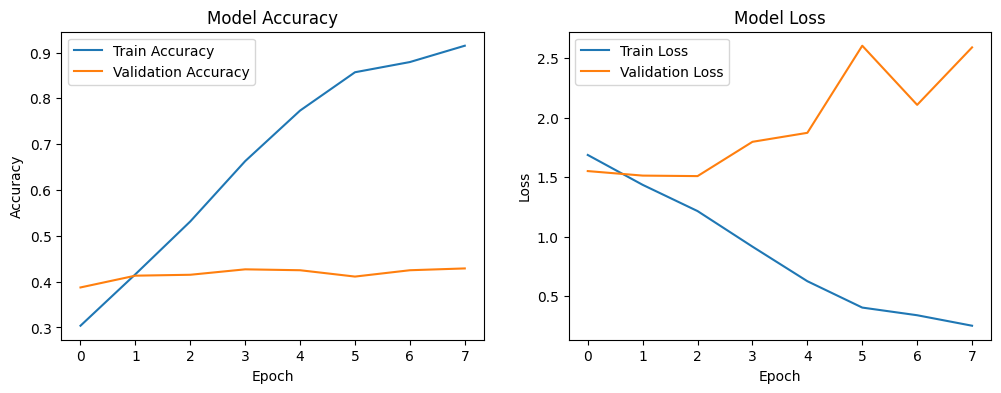

In [ ]:
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
